# 09 · The Poisson process

Arrivals of calls, customers, failures, photons or insurance claims are, to a first approximation, a Poisson
process: independent counts in disjoint intervals, exponential gaps, uniformly scattered times given their
number. This notebook builds the process three ways, makes it non-homogeneous (thinning and time change),
compounds and splits it, scatters it in the plane - and tests it on 20 days of a call centre's arrival log.

**What you will learn**
- construct homogeneous and non-homogeneous Poisson processes
- estimate a time-varying rate and test the Poisson assumptions on data
- use compound, split and superposed processes
- simulate spatial Poisson processes

**Before you start:** notebooks 01-02; the exponential and Poisson distributions  ·  **Time:** about 75 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from engstoch import poisson as pp, models, datasets, rngtests as rt
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Three constructions of one process

In [2]:
rate, T = 3.0, 2.0
a = [len(pp.homogeneous(rate, T, R(k))) for k in range(20_000)]
b = [len(pp.homogeneous_order_statistics(rate, T, R(k))) for k in range(20_000)]
print(f"N(2) by exponential gaps: mean {np.mean(a):.3f}, var {np.var(a):.3f}; by Poisson count + sorted uniforms: mean {np.mean(b):.3f}, var {np.var(b):.3f}; theory 6, 6")
t = pp.homogeneous(rate, 5000.0, R(1))
gaps = pp.interarrival_gaps(t)
print(f"gaps: mean {gaps.mean():.4f} (1/3), cv {gaps.std() / gaps.mean():.3f} (1), KS p vs Exp(3) = {rt.ks_test(gaps, lambda x: 1 - np.exp(-3 * x))['p_value']:.3f}")
print(f"memorylessness: P(gap > 0.5 | gap > 0.3) = {np.mean(gaps[gaps > 0.3] > 0.5):.4f} vs P(gap > 0.2) = {np.mean(gaps > 0.2):.4f}")

N(2) by exponential gaps: mean 6.003, var 5.919; by Poisson count + sorted uniforms: mean 6.015, var 6.117; theory 6, 6
gaps: mean 0.3320 (1/3), cv 1.000 (1), KS p vs Exp(3) = 0.950
memorylessness: P(gap > 0.5 | gap > 0.3) = 0.5423 vs P(gap > 0.2) = 0.5498


Exponential gaps, a Poisson number of uniform points, and (implicitly) independent Poisson counts in small
intervals are three equivalent definitions. The exponential's memorylessness is the defining property: having
waited does not bring the next arrival closer.

## Non-homogeneous arrivals: thinning and time change

one simulated day: 1063 calls; expected 1067.9; thinning acceptance 0.270
by inverting the cumulative intensity: 1056 calls


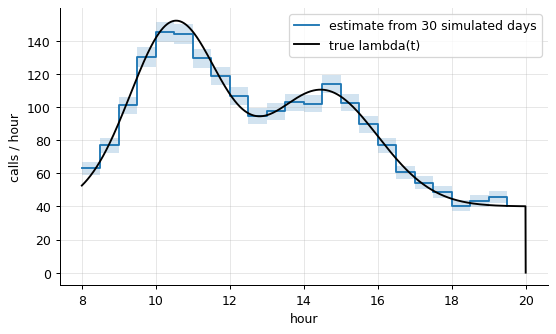

In [3]:
lam = models.call_centre_rate
th = pp.thinning(lam, 160.0, 24.0, R(2))
print(f"one simulated day: {len(th['times'])} calls; expected {pp.cumulative_intensity(lam, 24.0, 20001):.1f}; thinning acceptance {th['acceptance']:.3f}")
grid = np.linspace(8, 20, 2001)
cum = np.r_[0, np.cumsum(0.5 * (lam(grid[1:]) + lam(grid[:-1])) * np.diff(grid))]
tc = pp.time_change(lambda e: np.interp(e, cum, grid), cum[-1], R(3))
print(f"by inverting the cumulative intensity: {len(tc)} calls")
days = [pp.thinning(lam, 160.0, 24.0, R(10 + k))["times"] for k in range(30)]
ie = pp.intensity_estimate(days, np.arange(8, 20.5, 0.5))
plt.step(ie["edges"][:-1], ie["rate"], where="post", label="estimate from 30 simulated days"); plt.plot(grid, lam(grid), "k", label="true lambda(t)")
plt.fill_between(ie["edges"][:-1], ie["rate"] - 2 * ie["std_error"], ie["rate"] + 2 * ie["std_error"], step="post", alpha=0.2); plt.legend(); plt.xlabel("hour"); plt.ylabel("calls / hour"); plt.show()

Thinning (Lewis and Shedler) generates candidates at the peak rate and keeps each with probability λ(t)/λ_max
- simple, exact, and wasteful when the peak is much higher than the average (here, over a 24-hour day with
the centre closed half of it, only 27 % are kept). The time
change maps a unit-rate process through the inverse cumulative intensity Λ⁻¹ and wastes nothing.

## The call-centre log

           mean   std  count
weekday                     
Fri      1084.5  50.1      4
Mon      1231.0  22.1      4
Thu      1087.2  37.1      4
Tue      1081.5  35.3      4
Wed      1061.2  70.2      4

dispersion test, all 20 daily totals: {'index': 5.1055, 'statistic': 97.0046, 'df': 19, 'p_value': 0.0}
dispersion test, Tuesday-Friday except day 8: {'index': 1.0378, 'statistic': 14.5293, 'df': 14, 'p_value': 0.8221}


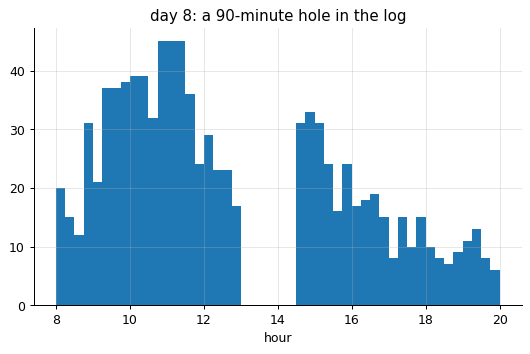

In [4]:
cc = pd.read_csv(datasets.path("call_centre.csv"), comment="#")
per_day = cc.groupby(["day", "weekday"]).size().reset_index(name="calls")
print(per_day.groupby("weekday").calls.agg(["mean", "std", "count"]).round(1))
print("\ndispersion test, all 20 daily totals:", {k: round(v, 4) for k, v in pp.dispersion_test(per_day.calls).items()})
non_mon = per_day[(per_day.weekday != "Mon") & (per_day.day != 8)].calls
print("dispersion test, Tuesday-Friday except day 8:", {k: round(v, 4) for k, v in pp.dispersion_test(non_mon).items()})
d8 = cc[cc.day == 8].arrival_h
plt.hist(d8, bins=np.arange(8, 20.25, 0.25)); plt.title("day 8: a 90-minute hole in the log"); plt.xlabel("hour"); plt.show()

Daily totals are overdispersed - the variance exceeds the mean - which rejects a single Poisson process with a
fixed daily profile. Two documented causes explain it: Mondays carry about 15 % more calls, and day 8 lost an
afternoon to a telephony outage. Excluding both, the remaining days are consistent with Poisson counts. Real
arrival data almost always show this extra variability (a "doubly stochastic" or Cox process); staffing models
that ignore it under-provision.

## Within-hour behaviour: conditional uniformity

In [5]:
rows = []
for day in (2, 3, 4):
    for h0 in (9, 13, 17):
        t = cc[(cc.day == day) & (cc.arrival_h >= h0) & (cc.arrival_h < h0 + 0.5)].arrival_h.to_numpy() - h0
        rows.append((day, f"{h0}:00-{h0}:30", len(t), pp.uniformity_test(t, 0.5)["p_value"], rt.ks_test(np.diff(t), lambda x: 1 - np.exp(-len(t) / 0.5 * x))["p_value"]))
print(pd.DataFrame(rows, columns=["day", "window", "calls", "uniformity KS p", "exponential gaps KS p"]).to_string(index=False, float_format="%.3f"))
r = pp.rate_mle(int(((cc.day == 3) & (cc.arrival_h >= 10) & (cc.arrival_h < 11)).sum()), 1.0)
print(f"\nday 3, 10:00-11:00: rate {r['rate']:.0f} calls/h, exact 95 % interval ({r['ci'][0]:.0f}, {r['ci'][1]:.0f}); model value {models.call_centre_rate(10.5):.0f}")

 day      window  calls  uniformity KS p  exponential gaps KS p
   2   9:00-9:30     49            0.884                  0.995
   2 13:00-13:30     45            0.348                  0.990
   2 17:00-17:30     13            0.679                  0.517
   3   9:00-9:30     64            0.703                  0.910
   3 13:00-13:30     58            0.772                  0.733
   3 17:00-17:30     22            0.906                  0.514
   4   9:00-9:30     42            0.355                  0.820
   4 13:00-13:30     55            0.607                  0.947
   4 17:00-17:30     33            0.862                  0.480

day 3, 10:00-11:00: rate 155 calls/h, exact 95 % interval (132, 181); model value 152


Over half an hour the rate is roughly constant, and given their number the arrival times should be uniform
(the order-statistics property) with exponential gaps - both tests pass. The Garwood interval, built from
chi-square quantiles, is exact for a Poisson count.

## Compound, split and spatial processes

In [6]:
tot = [pp.compound(5.0, 10.0, lambda n, r: r.lognormal(1.0, 0.8, n), R(k))["total"] for k in range(20_000)]
EY, EY2 = np.exp(1.0 + 0.32), np.exp(2.0 + 2 * 0.64)
mom = pp.compound_moments(5.0, 10.0, EY, EY2)
print(f"compound Poisson claims: mean {np.mean(tot):.1f} (theory {mom['mean']:.1f}), sd {np.std(tot):.1f} (theory {np.sqrt(mom['var']):.1f}), 99.5 % quantile {np.quantile(tot, 0.995):.0f}")
types = pp.split(pp.homogeneous(10.0, 1000.0, R(4)), [0.2, 0.8], R(5))
c1, c2 = pp.counts_in_windows(types[0], np.arange(0, 1001, 1)), pp.counts_in_windows(types[1], np.arange(0, 1001, 1))
print(f"split stream: rates {len(types[0]) / 1000:.2f} and {len(types[1]) / 1000:.2f}, correlation of counts per unit time {np.corrcoef(c1, c2)[0, 1]:.3f}")
pts = pp.spatial_rectangle(50.0, 2.0, 1.0, R(6))
grid = np.stack(np.meshgrid(np.linspace(0, 2, 60), np.linspace(0, 1, 30)), -1).reshape(-1, 2)
dist = np.min(np.hypot(grid[:, None, 0] - pts[None, :, 0], grid[:, None, 1] - pts[None, :, 1]), axis=1)
print(f"spatial process with 50 points per unit area: {len(pts)} points; P(nearest point within 0.1) = {np.mean(dist <= 0.1):.3f} vs 1 - exp(-50 pi 0.01) = {pp.nearest_neighbour_cdf(0.1, 50.0):.3f} (edge effects lower it)")

compound Poisson claims: mean 186.9 (theory 187.2), sd 36.3 (theory 36.5), 99.5 % quantile 293
split stream: rates 2.03 and 7.97, correlation of counts per unit time -0.008
spatial process with 50 points per unit area: 101 points; P(nearest point within 0.1) = 0.787 vs 1 - exp(-50 pi 0.01) = 0.792 (edge effects lower it)


A compound Poisson sum has mean λtE[Y] and variance λtE[Y²] - the variance depends on the second moment of the
claim size, so heavy-tailed claims dominate the risk. Randomly typing the arrivals of a Poisson process
produces *independent* Poisson streams - a remarkable property that makes routing calls to skills or sorting
parts by defect type tractable. In the plane, counts in regions are Poisson and the distance to the nearest
point has the law 1 − e^{−λπr²}, the starting point of spatial statistics.

## Inside the algorithm: Lewis-Shedler thinning in five lines

In [7]:
g = R(21); t, kept = 0.0, []
while True:
    t += g.exponential(1 / 160.0)
    if t > 24: break
    if g.random() < models.call_centre_rate(t) / 160.0: kept.append(t)
print(f"{len(kept)} arrivals; expected {pp.cumulative_intensity(models.call_centre_rate, 24.0, 20001):.0f}")

1017 arrivals; expected 1068


## Exercises
1. Using the call-centre data, test whether the Monday profile is a scaled copy of the Tuesday-Friday profile: estimate half-hourly rates for both and test the ratio for constancy (a chi-square test on the Monday counts given the scaled profile).
2. Simulate a Cox process whose daily rate is the call-centre profile times a Gamma(shape 20, mean 1) day factor, and show that it reproduces the overdispersion of daily totals that a Poisson process cannot.
3. **Implement it yourself:** simulate a non-homogeneous Poisson process by inverting the cumulative intensity of lambda(t) = 2 + sin(t) on [0, 50] with a root finder, and check the counts in [0, 10] and [10, 20] against their Poisson laws.